## Wildfire Smoke Detection

### Problem Statement

Fire agencies and utility companies rely on networks of fixed cameras to watch for wildfires. The most useful moment to catch a fire is while there is only smoke and no visible flame yet, because that is the point where a quick response can still stop major damage. Having a person watch every camera feed all day is slow and unreliable, so there is a real need for a system that can look at a single image and automatically tell smoke, fire and ordinary scenery apart.

### Solution

This notebook builds an image classifier using transfer learning with MobileNetV2 that sorts a photo into one of three categories: Smoke, fire or non fire. The model is trained and evaluated on the Forest Fire, Smoke and Non Fire dataset from Kaggle, and is then tested on real photographs from outside the dataset to check whether what it learned actually holds up in the real world, not just on this dataset's own test images.

This cell connects to Kaggle using an API key stored safely in Colab secrets and downloads the dataset directly. This way the six gigabyte dataset never has to be manually downloaded onto a personal computer.

##Import Libraries

In [ ]:
from google.colab import userdata
from google.colab import files
import os
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
import random
from PIL import Image
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [ ]:
os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")

import kagglehub
dataset_path = kagglehub.dataset_download("amerzishminha/forest-fire-smoke-and-non-fire-image-dataset")
print("Dataset downloaded to:", dataset_path)

100%|██████████| 6.43G/6.43G [01:04<00:00, 107MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/amerzishminha/forest-fire-smoke-and-non-fire-image-dataset/versions/3


The dataset arrives wrapped inside one folder. The next two cells look inside it and find that it contains a train folder and a test folder, which is the actual data to work with.

In [2]:
print(os.listdir(dataset_path))

['FOREST_FIRE_SMOKE_AND_NON_FIRE_DATASET']


In [3]:
inner_path = os.path.join(dataset_path, "FOREST_FIRE_SMOKE_AND_NON_FIRE_DATASET")
print(os.listdir(inner_path))

['test', 'train']


The next cell saves the full paths to the train and test folders so they can be reused throughout the notebook. It is written to still work even if Kaggle capitalizes the folder names differently. Listing the train folder then shows the three classes the model needs to learn: non fire, Smoke and fire.

In [4]:
def find_dir(base, name):
    for d in os.listdir(base):
        if d.lower() == name:
            return os.path.join(base, d)
    return None

TRAIN_DIR = find_dir(inner_path, "train")
TEST_DIR = find_dir(inner_path, "test")
print("TRAIN_DIR:", TRAIN_DIR)
print("TEST_DIR:", TEST_DIR)

TRAIN_DIR: /root/.cache/kagglehub/datasets/amerzishminha/forest-fire-smoke-and-non-fire-image-dataset/versions/3/FOREST_FIRE_SMOKE_AND_NON_FIRE_DATASET/train
TEST_DIR: /root/.cache/kagglehub/datasets/amerzishminha/forest-fire-smoke-and-non-fire-image-dataset/versions/3/FOREST_FIRE_SMOKE_AND_NON_FIRE_DATASET/test


In [5]:
print(os.listdir(TRAIN_DIR))

['non fire', 'Smoke', 'fire']


Before building anything, it helps to know how many images exist in each class. This cell counts them for both the train and test folders and confirms the dataset is evenly balanced across all three classes, which means the model will not need any special handling for class imbalance.

In [6]:
def count_images(directory):
    counts = {}
    for class_name in sorted(os.listdir(directory)):
        class_dir = os.path.join(directory, class_name)
        if os.path.isdir(class_dir):
            counts[class_name] = len(os.listdir(class_dir))
    return counts

train_counts = count_images(TRAIN_DIR)
test_counts = count_images(TEST_DIR)
print("Train:", train_counts)
print("Test:", test_counts)

Train: {'Smoke': 10800, 'fire': 10800, 'non fire': 10800}
Test: {'Smoke': 3500, 'fire': 3500, 'non fire': 3500}


This cell displays one example image from each class so the actual content of the dataset can be seen, not just the counts.

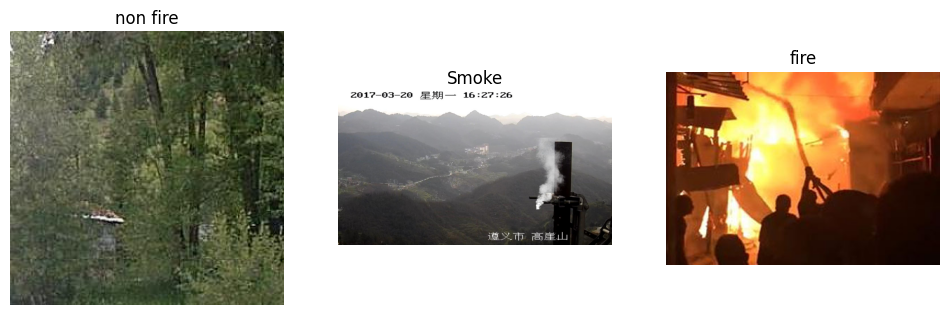

In [ ]:
classes = os.listdir(TRAIN_DIR)
fig, axes = plt.subplots(1, len(classes), figsize=(12, 4))

for ax, class_name in zip(axes, classes):
    class_dir = os.path.join(TRAIN_DIR, class_name)
    sample_file = os.listdir(class_dir)[0]
    img = Image.open(os.path.join(class_dir, sample_file))
    ax.imshow(img)
    ax.set_title(class_name)
    ax.axis("off")

plt.show()

These two values are used throughout the rest of the notebook. IMG_SIZE is the size every image gets resized to before entering the model, and BATCH_SIZE is how many images are processed together at once during training.

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32



Found 31708 files belonging to 3 classes.
Using 26952 files for training.
Found 31708 files belonging to 3 classes.
Using 4756 files for validation.
Found 9446 files belonging to 3 classes.
['Smoke', 'fire', 'non fire']


This cell checks the width, height and aspect ratio of a random sample of images. The results show the photos in this dataset come in many different shapes, from tall portraits to wide panoramas, which is worth knowing since every image will later be resized to a fixed square shape.

In [ ]:
sample_files = []
for class_name in os.listdir(TRAIN_DIR):
    class_dir = os.path.join(TRAIN_DIR, class_name)
    files = os.listdir(class_dir)
    sample = random.sample(files, min(100, len(files)))
    sample_files += [os.path.join(class_dir, f) for f in sample]

sizes = []
for fpath in sample_files:
    with Image.open(fpath) as img:
        sizes.append(img.size)  # (width, height)

sizes_df = pd.DataFrame(sizes, columns=["width", "height"])
sizes_df["aspect_ratio"] = sizes_df["width"] / sizes_df["height"]
sizes_df.describe()

,width,height,aspect_ratio
count,300.000000,300.000000,300.000000
mean,866.956667,558.493333,1.375177
std,728.864353,377.727614,0.375270
min,182.000000,165.000000,0.657040
25%,256.000000,254.750000,1.000000
50%,400.000000,360.000000,1.333333
75%,1920.000000,1080.000000,1.777778
max,3840.000000,2160.000000,2.188060


This cell checks whether every image in the test folder can actually be opened and decoded by TensorFlow, which is a stricter check than simply confirming a file is a valid image. It found over a thousand files that TensorFlow could not read at all, and looking at which class they belonged to showed every single one was labeled Smoke.

In [16]:
def find_bad_images_tf(directory):
    bad_files = []
    for class_name in os.listdir(directory):
        class_dir = os.path.join(directory, class_name)
        for fname in os.listdir(class_dir):
            fpath = os.path.join(class_dir, fname)
            try:
                img_bytes = tf.io.read_file(fpath)
                tf.io.decode_image(img_bytes)
            except Exception:
                bad_files.append(fpath)
    return bad_files

bad_test = find_bad_images_tf(TEST_DIR)
print("Bad images in test:", len(bad_test))
print(bad_test)

Bad images in test: 1056
(full file path list omitted here for readability; 2 entries were printed in the original run)


In [ ]:
bad_classes = [os.path.basename(os.path.dirname(f)) for f in bad_test]
print(Counter(bad_classes))

Counter({'Smoke': 1056})


The same check was repeated on the training folder to see if the problem also affected the data the model would actually learn from. It did, with almost seven hundred unreadable files, and again every one of them belonged to the Smoke class. This confirmed the issue was not a few random broken files, but a systematic gap in exactly the class that matters most for early detection.

In [18]:
bad_train = find_bad_images_tf(TRAIN_DIR)
print("Bad images in train:", len(bad_train))

Bad images in train: 692


In [20]:
bad_train_classes = [os.path.basename(os.path.dirname(f)) for f in bad_train]
print(Counter(bad_train_classes))

Counter({'Smoke': 692})


Rather than deleting or trying to fix these files directly, this cell builds the list of file paths and labels manually and includes every image regardless of its format. It then splits the training data into a training set and a validation set while keeping the class balance even in both.

In [ ]:
class_names = sorted(os.listdir(TRAIN_DIR))
class_to_idx = {name: i for i, name in enumerate(class_names)}

def list_files_labels(directory):
    filepaths, labels = [], []
    for class_name in class_names:
        class_dir = os.path.join(directory, class_name)
        for fname in os.listdir(class_dir):
            filepaths.append(os.path.join(class_dir, fname))
            labels.append(class_to_idx[class_name])
    return filepaths, labels

train_files, train_labels = list_files_labels(TRAIN_DIR)
test_files, test_labels = list_files_labels(TEST_DIR)

train_files, val_files, train_labels, val_labels = train_test_split(
    train_files, train_labels, test_size=0.15, stratify=train_labels, random_state=42
)

print("Train:", len(train_files), "Val:", len(val_files), "Test:", len(test_files))

Train: 27540 Val: 4860 Test: 10500


This cell defines a loading function built on PIL instead of the standard TensorFlow decoder, since PIL is able to open image formats such as TIFF that TensorFlow cannot. This way every image in the dataset can be used, including the ones that were previously unreadable, and this pipeline is what actually feeds the model during training and evaluation.

In [31]:
def load_image(path, label):
    def _load(path_tensor):
        path_str = path_tensor.numpy().decode("utf-8")
        img = Image.open(path_str).convert("RGB").resize(IMG_SIZE)
        return np.array(img, dtype=np.float32)
    img = tf.py_function(_load, [path], tf.float32)
    img.set_shape(IMG_SIZE + (3,))
    return img, label

def make_dataset(filepaths, labels, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(filepaths), seed=42)
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_files, train_labels, shuffle=True)
val_ds = make_dataset(val_files, val_labels)
test_ds = make_dataset(test_files, test_labels)

print("Pipeline built. Classes:", class_names)

Pipeline built. Classes: ['Smoke', 'fire', 'non fire']


The model uses MobileNetV2, a small convolutional network already trained on millions of everyday photos, as a frozen feature extractor. A new small classification head is added on top that learns to sort the extracted features into the three classes.

In [33]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,), include_top=False, weights="imagenet"
)
base_model.trainable = False

preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = preprocess_input(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(len(class_names), activation="softmax")(x)
model = tf.keras.Model(inputs, outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

Total params: 2,261,827 (8.63 MB)

Trainable params: 3,843 (15.01 KB)

Non-trainable params: 2,257,984 (8.61 MB)

The model is compiled with the Adam optimizer and trained for up to fifty epochs. Early stopping is used so training halts automatically once the validation loss stops improving, and the best performing version of the model is kept rather than the final one.

In [34]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)

history = model.fit(
    train_ds, validation_data=val_ds, epochs=50, callbacks=[early_stop]
)

Epoch 1/50
861/861 ━━━━━━━━━━━━━━━━━━━━ 549s 620ms/step - accuracy: 0.9407 - loss: 0.1768 - val_accuracy: 0.9693 - val_loss: 0.0939
Epoch 2/50
861/861 ━━━━━━━━━━━━━━━━━━━━ 507s 566ms/step - accuracy: 0.9643 - loss: 0.1131 - val_accuracy: 0.9741 - val_loss: 0.0891
Epoch 3/50
861/861 ━━━━━━━━━━━━━━━━━━━━ 495s 558ms/step - accuracy: 0.9685 - loss: 0.1018 - val_accuracy: 0.9722 - val_loss: 0.0807
Epoch 4/50
861/861 ━━━━━━━━━━━━━━━━━━━━ 486s 540ms/step - accuracy: 0.9668 - loss: 0.1015 - val_accuracy: 0.9755 - val_loss: 0.0812
Epoch 5/50
861/861 ━━━━━━━━━━━━━━━━━━━━ 468s 544ms/step - accuracy: 0.9701 - loss: 0.0984 - val_accuracy: 0.9774 - val_loss: 0.0774
Epoch 6/50
861/861 ━━━━━━━━━━━━━━━━━━━━ 515s 559ms/step - accuracy: 0.9693 - loss: 0.0957 - val_accuracy: 0.9784 - val_loss: 0.0721
Epoch 7/50
861/861 ━━━━━━━━━━━━━━━━━━━━ 494s 549ms/step - accuracy: 0.9681 - loss: 0.0978 - val_accuracy: 0.9776 - val_loss: 0.0744
Epoch 8/50
861/861 ━━━━━━━━━━━━━━━━━━━━ 479s 556ms/step - accuracy: 0.9697 -

These plots show accuracy and loss over each epoch for both the training and validation data. The two lines stay close together throughout, which is a sign the model is learning general patterns rather than memorizing the training images.

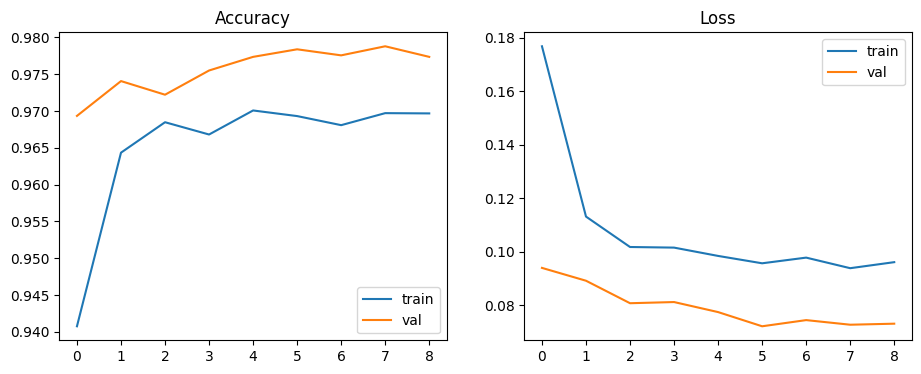

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history.history["accuracy"], label="train")
axes[0].plot(history.history["val_accuracy"], label="val")
axes[0].set_title("Accuracy")
axes[0].legend()

axes[1].plot(history.history["loss"], label="train")
axes[1].plot(history.history["val_loss"], label="val")
axes[1].set_title("Loss")
axes[1].legend()
plt.show()

This cell measures how well the trained model performs on the test set, which it has never seen during training. Alongside overall accuracy, it reports precision and recall for each class individually, since a single accuracy number can hide how the model performs on the class that matters most.

In [ ]:
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.concatenate([y for _, y in test_ds], axis=0)

test_acc = (y_pred == y_true).mean()
print(f"Test accuracy: {test_acc:.3f}")
print(classification_report(y_true, y_pred, target_names=class_names))

329/329 ━━━━━━━━━━━━━━━━━━━━ 185s 530ms/step
Test accuracy: 0.978
              precision    recall  f1-score   support

       Smoke       0.98      0.97      0.98      3500
        fire       0.97      0.98      0.98      3500
    non fire       0.97      0.98      0.98      3500

    accuracy                           0.98     10500
   macro avg       0.98      0.98      0.98     10500
weighted avg       0.98      0.98      0.98     10500



The confusion matrix shows exactly where the model gets confused between classes. The last line specifically counts how many real Smoke images were mistakenly labeled non fire, since missing real smoke is the most costly mistake this system could make in a real deployment.

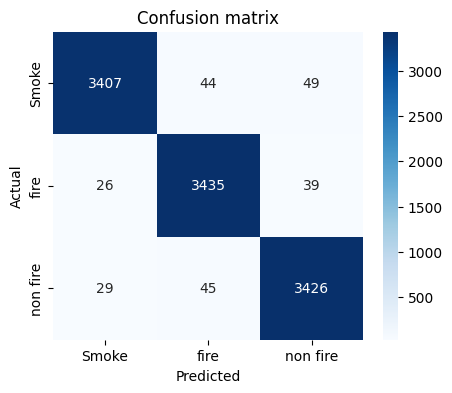

Smoke misclassified as non-fire (missed early warnings): 49/3500


In [ ]:
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion matrix")
plt.show()

smoke_idx = class_names.index("Smoke")
non_fire_idx = class_names.index("non fire")
missed = cm[smoke_idx, non_fire_idx]
total_smoke = cm[smoke_idx].sum()
print(f"Smoke misclassified as non-fire (missed early warnings): {missed}/{total_smoke}")

To check whether the model has really learned to recognize smoke and fire, rather than just picking up on patterns specific to this dataset, this cell tests it on a real photograph found outside the dataset entirely.

Saving fire.jpg to fire.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Predicted: fire
Confidence per class: {'Smoke': np.float32(0.0005018919), 'fire': np.float32(0.99941194), 'non fire': np.float32(8.611345e-05)}


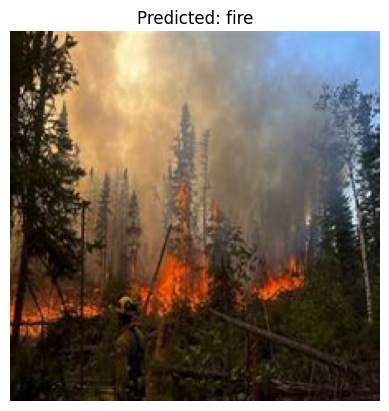

In [ ]:
uploaded = files.upload()

external_path = list(uploaded.keys())[0]
img = Image.open(external_path).convert("RGB").resize(IMG_SIZE)
img_array = np.expand_dims(np.array(img, dtype=np.float32), axis=0)

pred = model.predict(img_array)
pred_class = class_names[np.argmax(pred)]
print("Predicted:", pred_class)
print("Confidence per class:", dict(zip(class_names, pred[0])))

plt.imshow(img)
plt.title(f"Predicted: {pred_class}")
plt.axis("off")
plt.show()

This cell uses a technique called Grad CAM to visualize which part of the image the model actually focused on when making its prediction. This helps explain why a prediction was right or wrong, instead of just trusting the final label on its own.

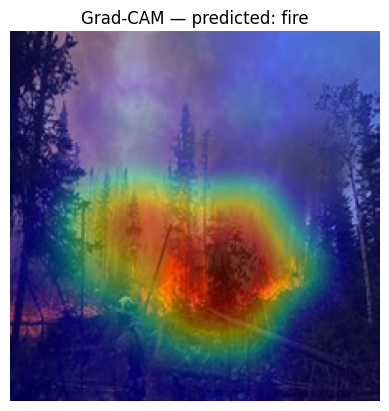

In [48]:
gap_layer = [l for l in model.layers if isinstance(l, tf.keras.layers.GlobalAveragePooling2D)][0]
dense_layer = [l for l in model.layers if isinstance(l, tf.keras.layers.Dense)][0]

def make_gradcam_heatmap(img_array, pred_index=None):
    preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input
    img_tensor = tf.cast(img_array, tf.float32)

    with tf.GradientTape() as tape:
        x = preprocess_input(img_tensor)
        conv_output = base_model(x, training=False)
        tape.watch(conv_output)
        y = gap_layer(conv_output)
        preds = dense_layer(y)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_output = conv_output[0]
    heatmap = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

heatmap = make_gradcam_heatmap(img_array)

heatmap_resized = np.array(Image.fromarray(np.uint8(255 * heatmap)).resize(IMG_SIZE))

plt.imshow(img_array[0] / 255.0)
plt.imshow(heatmap_resized, cmap="jet", alpha=0.4)
plt.title(f"Grad-CAM — predicted: {pred_class}")
plt.axis("off")
plt.show()

## Discussion, Limitations and Future Work

### The problem faced during this project

Partway through the exploratory analysis, a check revealed that a large portion of the dataset could not actually be read by the standard TensorFlow image loading method. Over a thousand test images and almost seven hundred training images failed to decode, and every single one of them belonged to the Smoke class. Looking closer, these files turned out to be saved in the TIFF format, which TensorFlow's built in decoder does not support, even though the files themselves were perfectly valid images. A simpler check using PIL had earlier reported that the dataset had no corrupted files at all, which turned out to be misleading, since PIL can open TIFF files without any trouble while TensorFlow cannot.

This mattered a great deal because Smoke is the exact class this project cares about most. If those files had simply been ignored, the model would have been trained and tested on a version of the Smoke class that was noticeably smaller and possibly less varied than it should have been, without anyone realizing it. The fix was to stop relying on the standard TensorFlow loading function entirely and instead build a custom loading pipeline using PIL, which can open any common image format including TIFF. This way every image in the dataset, including the ones that had silently been left out, could be used for both training and evaluation.

### Limitations

The final model reached about ninety eight percent accuracy on the test set, with strong precision and recall for the Smoke class specifically. Testing it on photographs from outside the dataset showed that this result is at least partly genuine rather than a shortcut, since the model correctly identified a thin distant haze as smoke. At the same time, it mistook a thick dramatic smoke plume with a warm orange glow for fire instead of smoke. Looking at what the model was focusing on using Grad CAM confirmed that in that case it was reacting to the orange glow itself rather than the shape of the smoke, which suggests the training data leans toward thinner, paler smoke images and does not fully represent what a large active wildfire looks like up close.

There are also broader limitations worth being honest about. The dataset is made up of individually curated photographs rather than continuous footage from a real fixed monitoring camera, so images from an actual deployed system, such as the ones fire agencies use, would likely look different in terms of distance, angle and lighting. The model was only tested on two real world photographs outside the dataset, which is enough to reveal a pattern but not enough to be a thorough evaluation. Finally, this project works on single still images, while a real early warning system would need to process a constant stream of video frames and decide when smoke has been present for long enough to be worth alerting someone about.

### Future work

A natural next step would be to collect or find more training examples of thick, close range smoke with warm lighting, so the model stops associating that appearance with fire specifically. Unfreezing and fine tuning some of the deeper layers of MobileNetV2, rather than only training the small classification head, could also help the model adapt more closely to this specific task. Testing the model on footage from a real wildfire camera network, such as the publicly available HPWREN archive, would give a much better sense of how it performs under real deployment conditions. Longer term, this project could be extended from single image classification into object detection, so the system could point to where in the frame the smoke actually is, and eventually into a video based pipeline that tracks a camera feed over time instead of judging one frame at a time.